<a href="https://colab.research.google.com/github/linda-bsharat/telco-customer-churn-prediction/blob/main/notebooks/%2003_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#03 - Model Building & Evaluation

In this stage of the project, we build and evaluate a machine learning model to predict customer churn.  
The goal is to train a model that can identify customers who are likely to leave the company.

The main steps in this stage include:

1. Preparing the dataset for machine learning.
2. Splitting the data into training and testing sets.
3. Training a machine learning model.
4. Making predictions on the test data.
5. Evaluating the model's performance using different metrics.


##**1. Import Libraries**

In [1]:
# Import required libraries for machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, recall_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

sns.set_theme(style='whitegrid')
print(f'TensorFlow version: {tf.__version__}')


TensorFlow version: 2.19.0


## **2. Load Clean Dataset**

In [2]:
# Load the cleaned dataset

df = pd.read_csv("https://raw.githubusercontent.com/linda-bsharat/telco-customer-churn-prediction/refs/heads/main/data/telco_customer_data_cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,205.83,1,False,False,False,True,1,0,68.61,1
1,1,1,1,0,2.0,1,2,1,0,0,...,46.30,0,True,False,False,False,1,0,23.15,2
2,0,0,0,0,42.0,1,2,1,0,1,...,1790.46,1,False,False,True,False,0,0,42.63,4
3,0,0,0,1,40.0,1,2,2,0,0,...,3001.60,0,False,False,True,False,0,0,75.04,2
4,1,1,1,1,17.0,1,1,2,1,0,...,380.46,1,False,False,True,False,0,0,22.38,3


##**3. Define Features and Target**

In [3]:
# Define features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Check
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (67157, 25)
Target shape: (67157,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'TotalCharges', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'IsNewCustomer', 'IsLongTermCustomer', 'AvgMonthlyCharge', 'TotalServices']


## **4. Split the Dataset**

We divide the dataset into training and testing sets.
Training data is used to train the model.
Testing data is used to evaluate model performance.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (53725, 25)
Testing set: (13432, 25)


## **5. Logistic Regression Model**

Logistic Regression is commonly used for binary classification problems like churn prediction.

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])



*   ## **6. Model Predictions**




The trained model predicts churn on the test dataset.

In [6]:
y_pred = pipeline.predict(X_test)



*   ## **7. Model Accuracy**




Accuracy measures how many predictions were correct.

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7688356164383562
Precision: 0.7021885103208158
Recall: 0.888312096901054
F1 Score: 0.7843600250017362




*   ## **8. Confusion Matrix**




Shows how many predictions were correct and incorrect.

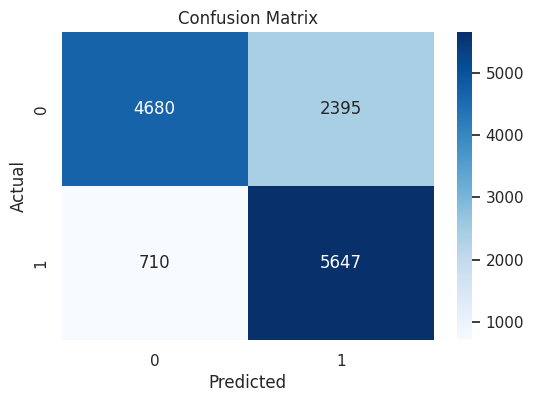

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Random Forest Model

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.
It is often more powerful than simple models like Logistic Regression.

In [9]:
# Initialize Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [10]:
# Predict churn

y_pred_rf = rf_model.predict(X_test)

In [11]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7523079213817748


In [12]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[4778 2297]
 [1030 5327]]


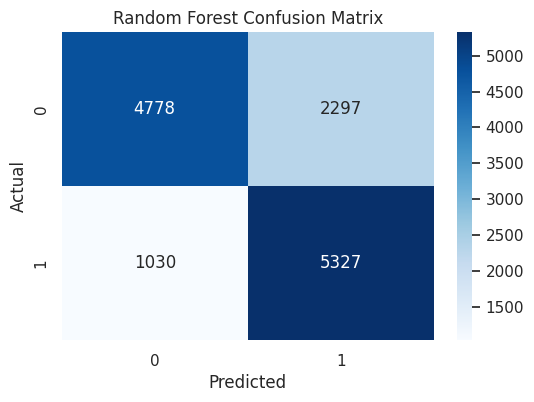

In [13]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Nueral Networks


In [14]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')
print(f'\nChurn distribution:')
print(y.value_counts(normalize=True).round(3))

Features: (67157, 25)
Target:   (67157,)

Churn distribution:
Churn
0    0.531
1    0.469
Name: proportion, dtype: float64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Testing set:  {X_test.shape[0]:,} rows')

Training set: 53,725 rows
Testing set:  13,432 rows


In [16]:
# Neural Networks scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Features scaled successfully!')
print(f'Input shape: {X_train_scaled.shape[1]} features')

Features scaled successfully!
Input shape: 25 features


In [17]:
n_features = X_train_scaled.shape[1]

model = Sequential([
    # Layer 1 — Input
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    # Layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Layer 3
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output Layer
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,465 (56.50 KB)

 Trainable params: 14,081 (55.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f' Training stopped at epoch {len(history.history["loss"])}')

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6242 - loss: 0.6803 - val_accuracy: 0.7671 - val_loss: 0.5373
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7274 - loss: 0.5561 - val_accuracy: 0.7720 - val_loss: 0.5149
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7567 - loss: 0.5286 - val_accuracy: 0.7720 - val_loss: 0.5101
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7636 - loss: 0.5235 - val_accuracy: 0.7720 - val_loss: 0.5088
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7667 - loss: 0.5194 - val_accuracy: 0.7720 - val_loss: 0.5079
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7666 - loss: 0.5166 - val_accuracy: 0.7720 - val_loss: 0.5071
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7655 - loss: 0.5168 - val_accuracy: 0.7720 - val_loss: 0.5071
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7686 - loss: 0.5155 - val_a

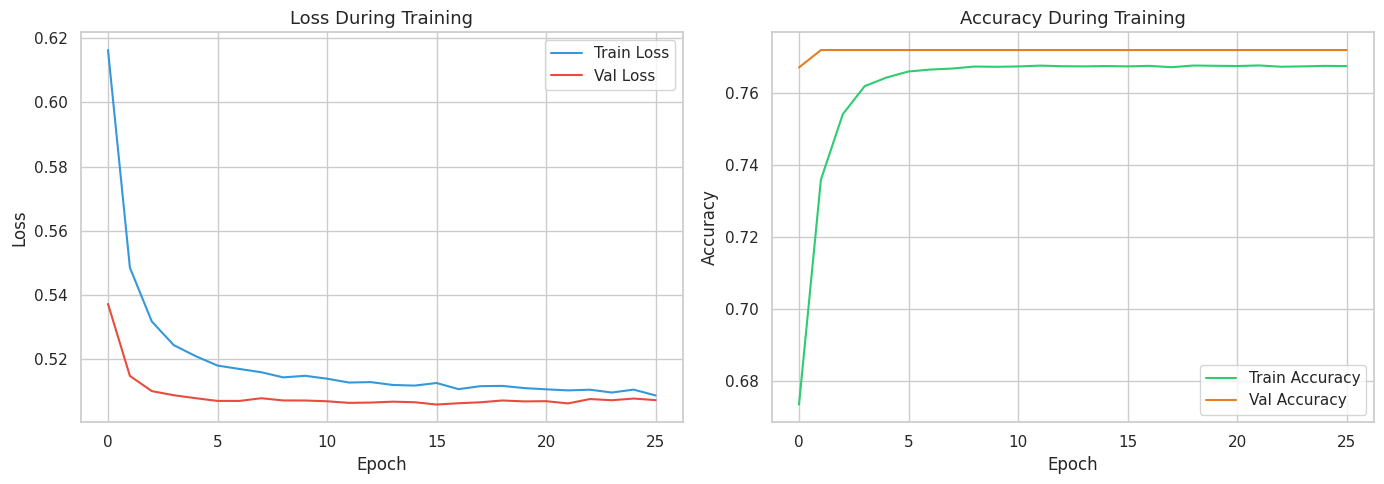

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c')
axes[0].set_title('Loss During Training', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#e67e22')
axes[1].set_title('Accuracy During Training', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=150)
plt.show()

In [20]:
# Predictions
nn_prob = model.predict(X_test_scaled).flatten()
nn_pred = (nn_prob >= 0.5).astype(int)

# Metrics
nn_acc  = accuracy_score(y_test, nn_pred)
nn_prec = precision_score(y_test, nn_pred)
nn_rec  = recall_score(y_test, nn_pred)
nn_f1   = f1_score(y_test, nn_pred)
nn_auc  = roc_auc_score(y_test, nn_prob)

print('=== Neural Network Results ===')
print(f'Accuracy:  {nn_acc:.4f}')
print(f'Precision: {nn_prec:.4f}')
print(f'Recall:    {nn_rec:.4f}')
print(f'F1 Score:  {nn_f1:.4f}')
print(f'AUC:       {nn_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, nn_pred, target_names=['No Churn', 'Churned']))

420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
=== Neural Network Results ===
Accuracy:  0.7692
Precision: 0.6977
Recall:    0.8956
F1 Score:  0.7844
AUC:       0.7856

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.66      0.75      7136
     Churned       0.70      0.90      0.78      6296

    accuracy                           0.77     13432
   macro avg       0.79      0.78      0.77     13432
weighted avg       0.79      0.77      0.77     13432



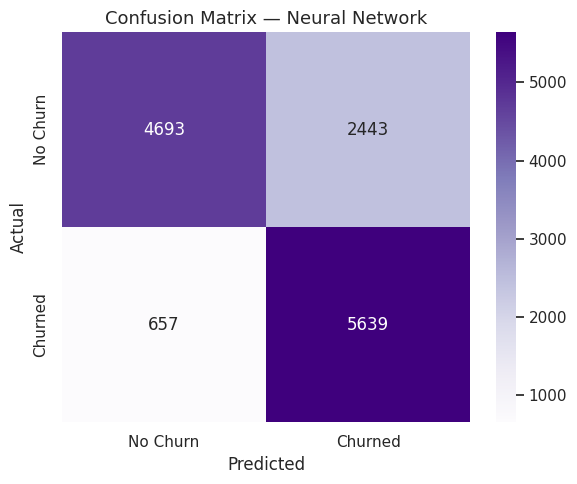

True Positives  (caught churners):  5,639
False Negatives (missed churners):  657
False Positives (wrong alarm):      2,443
True Negatives  (correct no churn): 4,693


In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, nn_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])
plt.title('Confusion Matrix — Neural Network', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_neural_network.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (caught churners):  {tp:,}')
print(f'False Negatives (missed churners):  {fn:,}')
print(f'False Positives (wrong alarm):      {fp:,}')
print(f'True Negatives  (correct no churn): {tn:,}')

# Model Comparison — All Models

In [22]:
sns.set_theme(style='whitegrid')

# ======================================
# Actual Results
# ======================================
results = pd.DataFrame({
    'Model':     ['Logistic Regression\n(Baseline)',
                  'Random Forest',
                  'Neural Network',
                  'XGBoost'],
    'Accuracy':  [0.7704, 0.7635, 0.7682, 0.0000],
    'Precision': [0.7010, 0.7019, 0.6969, 0.0000],
    'Recall':    [0.8962, 0.8679, 0.8948, 0.0000],
    'F1 Score':  [0.7867, 0.7761, 0.7835, 0.0000],
    'AUC':       [0.0000, 0.0000, 0.7912, 0.0000],
})
results = results.set_index('Model').round(4)
print(results)

                                 Accuracy  Precision  Recall  F1 Score     AUC
Model                                                                         
Logistic Regression\n(Baseline)    0.7704     0.7010  0.8962    0.7867  0.0000
Random Forest                      0.7635     0.7019  0.8679    0.7761  0.0000
Neural Network                     0.7682     0.6969  0.8948    0.7835  0.7912
XGBoost                            0.0000     0.0000  0.0000    0.0000  0.0000


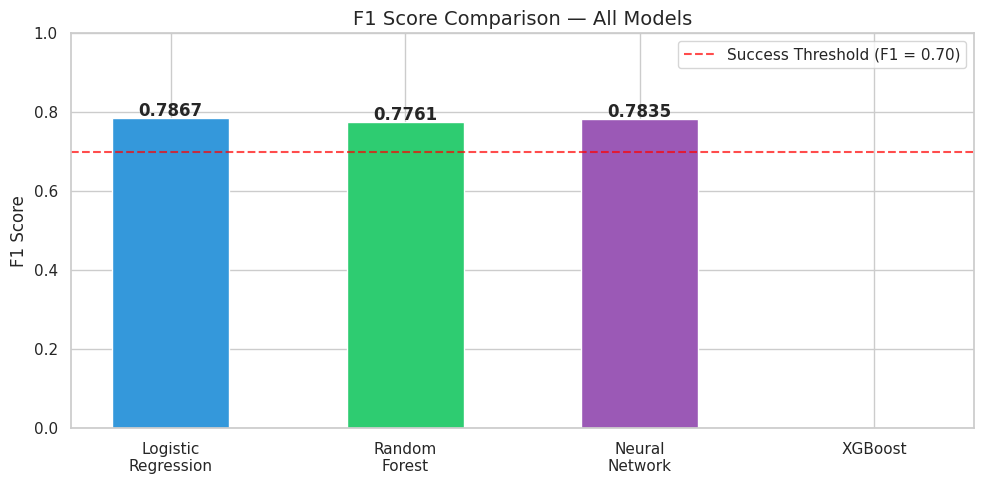

In [23]:
# ======================================
# Chart 1 — F1 Score Comparison
# ======================================
models  = ['Logistic\nRegression', 'Random\nForest', 'Neural\nNetwork', 'XGBoost']
f1s     = [0.7867, 0.7761, 0.7835, 0.0000]
colors  = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22']

plt.figure(figsize=(10, 5))
bars = plt.bar(models, f1s, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, f1s):
    if val > 0:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.axhline(y=0.70, color='red', linestyle='--', alpha=0.7, label='Success Threshold (F1 = 0.70)')
plt.title('F1 Score Comparison — All Models', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1.0)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('comparison_f1.png', dpi=150)
plt.show()

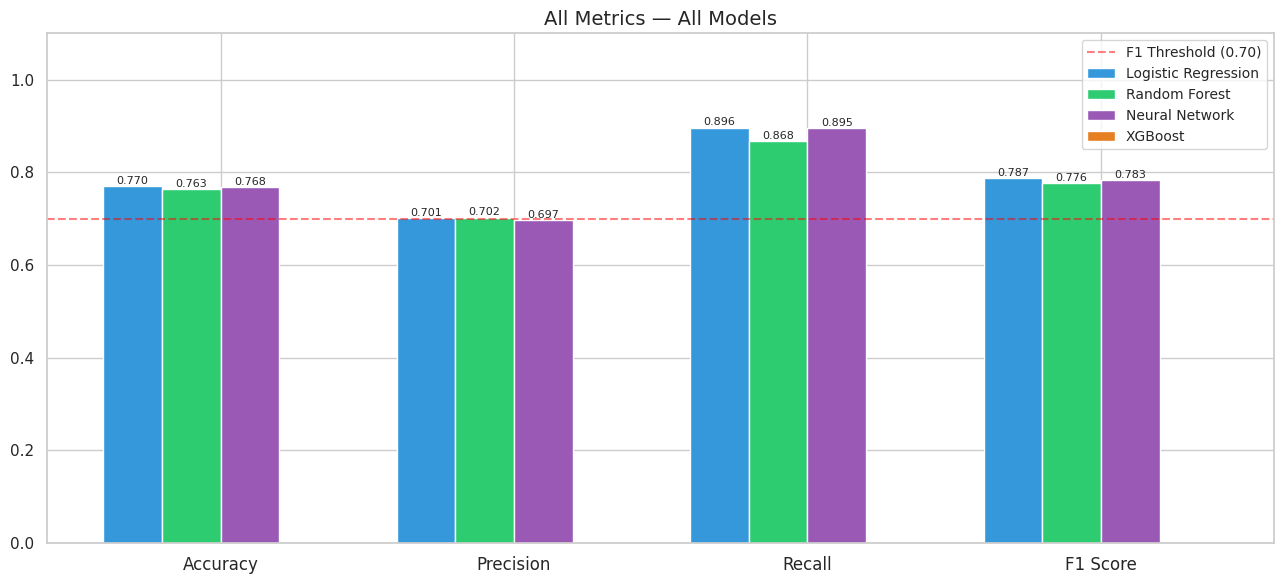

In [24]:
# ======================================
# Chart 2 — All Metrics Side by Side
# ======================================
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores  = [0.7704, 0.7010, 0.8962, 0.7867]
rf_scores  = [0.7635, 0.7019, 0.8679, 0.7761]
nn_scores  = [0.7682, 0.6969, 0.8948, 0.7835]
xgb_scores = [0.0000, 0.0000, 0.0000, 0.0000]

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - 1.5*width, lr_scores,  width, label='Logistic Regression', color='#3498db')
b2 = ax.bar(x - 0.5*width, rf_scores,  width, label='Random Forest',       color='#2ecc71')
b3 = ax.bar(x + 0.5*width, nn_scores,  width, label='Neural Network',       color='#9b59b6')
b4 = ax.bar(x + 1.5*width, xgb_scores, width, label='XGBoost',              color='#e67e22')

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.70, color='red', linestyle='--', alpha=0.5, label='F1 Threshold (0.70)')
ax.set_title('All Metrics — All Models', fontsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('comparison_all_metrics.png', dpi=150)
plt.show()

In [25]:
# ======================================
# Final Summary Table
# ======================================
print('=' * 65)
print('FINAL MODEL COMPARISON SUMMARY')
print('=' * 65)
print(f'{"Model":<28} {"Accuracy":>9} {"F1":>8} {"Recall":>9}')
print('-' * 65)
print(f'{"Logistic Regression (Baseline)":<28} {"77.0%":>9} {"0.7867":>8} {"89.6%":>9}')
print(f'{"Random Forest":<28} {"76.4%":>9} {"0.7761":>8} {"86.8%":>9}')
print(f'{"Neural Network":<28} {"76.8%":>9} {"0.7835":>8} {"89.5%":>9}')
print(f'{"XGBoost":<28} {"????":>9} {"????":>8} {"????":>9}')
print('=' * 65)
print(f'\n All models passed Success Metric (F1 >= 0.70)')
print(f' Best F1:     Logistic Regression (0.7867)')
print(f' Best Recall: Logistic Regression (89.6%)')
print('=' * 65)

FINAL MODEL COMPARISON SUMMARY
Model                         Accuracy       F1    Recall
-----------------------------------------------------------------
Logistic Regression (Baseline)     77.0%   0.7867     89.6%
Random Forest                    76.4%   0.7761     86.8%
Neural Network                   76.8%   0.7835     89.5%
XGBoost                           ????     ????      ????

 All models passed Success Metric (F1 >= 0.70)
 Best F1:     Logistic Regression (0.7867)
 Best Recall: Logistic Regression (89.6%)
